### Example of plotting results and using regression

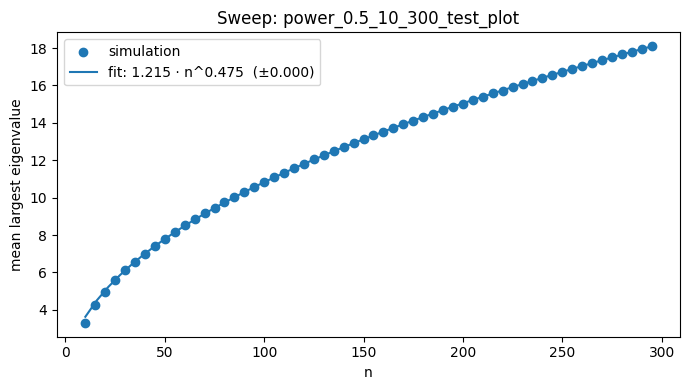

C = 1.2151 ± 0.0008
a = 0.4749 ± 0.0001


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

SWEEP_TAG = "power_0.5_10_300_test_plot"
CSV_PATH  = "../data/simulation_results.csv"

df = pd.read_csv(CSV_PATH)
df = df[df["sweep_tag"] == SWEEP_TAG].sort_values("n")

n    = df["n"].to_numpy()
y    = df["mean_eigenvalue"].to_numpy()
yerr = df["_std_error"].to_numpy()


def power_law(n, C, a):
    return C * n ** a

popt, pcov = curve_fit(power_law, n, y, sigma=yerr, absolute_sigma=True)
C, a = popt
perr = np.sqrt(np.diag(pcov))

n_fit  = np.linspace(n.min(), n.max())
y_fit  = power_law(n_fit, C, a)

fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(n, y, label="simulation")
ax.plot(n_fit, y_fit, label=f"fit: {C:.3f} · n^{a:.3f}  (±{perr[1]:.3f})")

ax.set_xlabel("n")
ax.set_ylabel("mean largest eigenvalue")
ax.set_title(f"Sweep: {SWEEP_TAG}")
ax.legend()

plt.tight_layout()
plt.show()

print(f"C = {C:.4f} ± {perr[0]:.4f}")
print(f"a = {a:.4f} ± {perr[1]:.4f}")